In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

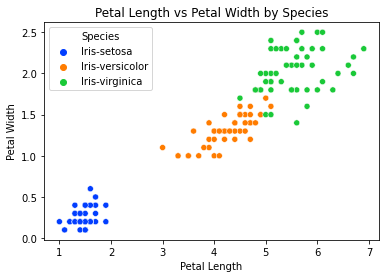

In [2]:
df = pd.read_csv("Iris.csv")
df.drop(columns=["Id"], inplace=True)
sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=df,
    palette="bright"
)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title("Petal Length vs Petal Width by Species")
plt.show()

In [3]:
encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

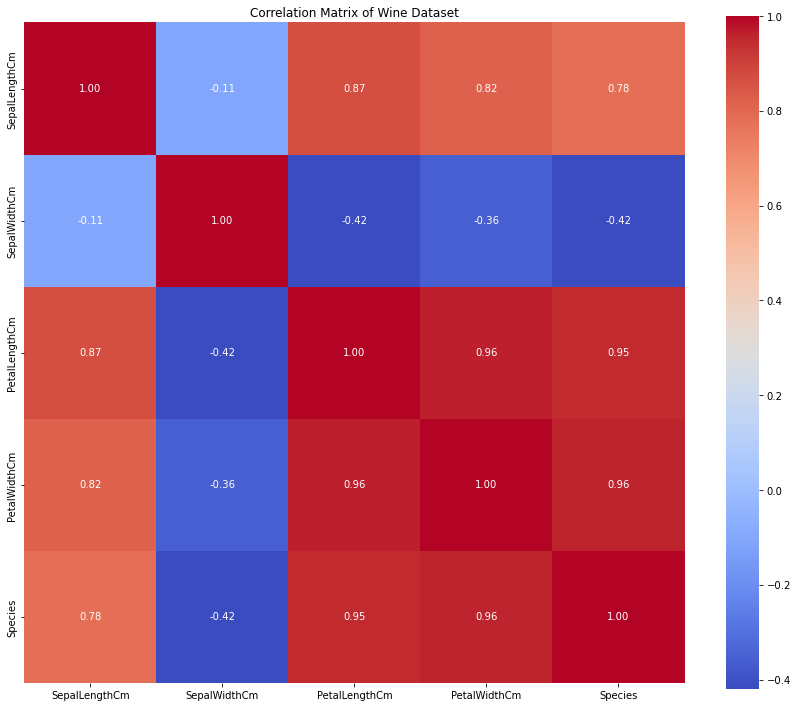

In [4]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Correlation Matrix of Wine Dataset")
plt.tight_layout()
plt.show()
plt.show()

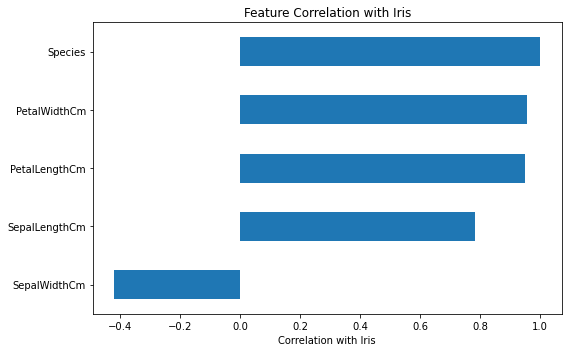

In [5]:
quality_corr = corr_matrix["Species"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
quality_corr.plot(kind="barh")
plt.xlabel("Correlation with Iris")
plt.title("Feature Correlation with Iris")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=["Species"]).values
y = df["Species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=2
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
class SoftmaxLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.loss_history = []

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y, n_classes):
        one_hot = np.zeros((y.shape[0], n_classes))
        one_hot[np.arange(y.shape[0]), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)

        y_onehot = self.one_hot(y, n_classes)

        for _ in range(self.n_iterations):
            logits = np.dot(X, self.W) + self.b
            y_hat = self.softmax(logits)

            error = y_hat - y_onehot

            dW = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error, axis=0)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            loss = -np.mean(np.sum(y_onehot * np.log(y_hat + 1e-9), axis=1))
            self.loss_history.append(loss)

    def predict(self, X):
        logits = np.dot(X, self.W) + self.b
        probs = self.softmax(logits)
        return np.argmax(probs, axis=1)

In [9]:
model = SoftmaxLogisticRegression(
    learning_rate=0.1,
    n_iterations=3000
)

model.fit(X_train, y_train)

In [10]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.98


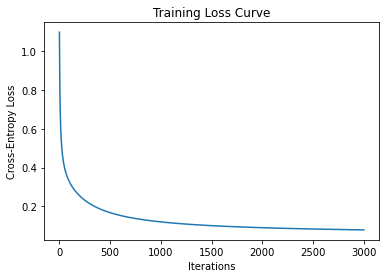

In [11]:
plt.figure()
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.show()

In [12]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[20  0  0]
 [ 0 15  1]
 [ 0  0 14]]


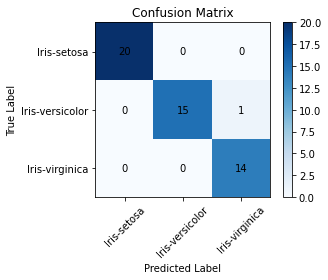

In [13]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

class_names = encoder.classes_

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()